# Chapter 06 — The Price of Intelligence

**Companion to Applied AI**

Question: How quickly does a per-call model cost become material at production scale?

By the end of this notebook you will have:

- built the chapter's invoice calculator
- computed per-call, per-user, and annual cost including retries
- plotted how trim/floor/cascade/distill/deterministic change the curve

## What this notebook demonstrates
A cost model with editable parameters. Prices are illustrative inputs, not quotes; replace them with your vendor's schedule.

In [1]:
SEED = 42
import random
random.seed(SEED)
print("seed:", SEED)
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

seed: 42


## 1. The invoice calculator

In [2]:
def invoice(input_tokens: int, output_tokens: int,
            in_price_per_m: float = 2.50, out_price_per_m: float = 10.00,
            ops_per_user_month: int = 120, users: int = 5000,
            retry_rate: float = 0.06, cache_hit_rate: float = 0.0) -> dict:
    billable = (1 - cache_hit_rate) * (1 + retry_rate)
    per_call = (input_tokens / 1e6 * in_price_per_m + output_tokens / 1e6 * out_price_per_m) * billable
    per_user_mo = per_call * ops_per_user_month
    return {"per_call": per_call, "per_user_mo": per_user_mo,
            "annual": per_user_mo * 12 * users}

base = invoice(1500, 600)
print({k: round(v, 4) if k == "per_call" else round(v, 2) for k, v in base.items()})
assert base["annual"] > base["per_user_mo"]

{'per_call': 0.0103, 'per_user_mo': 1.24, 'annual': 74412.0}


## 2. The ratchet: five moves that push the curve down

In [3]:
ratchet = {
    "baseline":             dict(),
    "trim (-40% tokens)":   dict(input_tokens=900, output_tokens=360),
    "cheaper floor model":  dict(in_price_per_m=0.50, out_price_per_m=2.00),
    "cascade (70% floor)":  dict(in_price_per_m=0.50 * 0.7 + 2.50 * 0.3,
                                 out_price_per_m=2.00 * 0.7 + 10.00 * 0.3),
    "distill (10x cheaper)":dict(in_price_per_m=0.25, out_price_per_m=1.00),
    "deterministic (80%)":  dict(ops_per_user_month=24),
}
for name, kw in ratchet.items():
    args = {"input_tokens": 1500, "output_tokens": 600}
    args.update(kw)
    print(f"{name:24s} annual = ${invoice(**args)['annual']:,.0f}")

baseline                 annual = $74,412
trim (-40% tokens)       annual = $44,647
cheaper floor model      annual = $14,882
cascade (70% floor)      annual = $32,741
distill (10x cheaper)    annual = $7,441
deterministic (80%)      annual = $14,882


## 3. Plot it

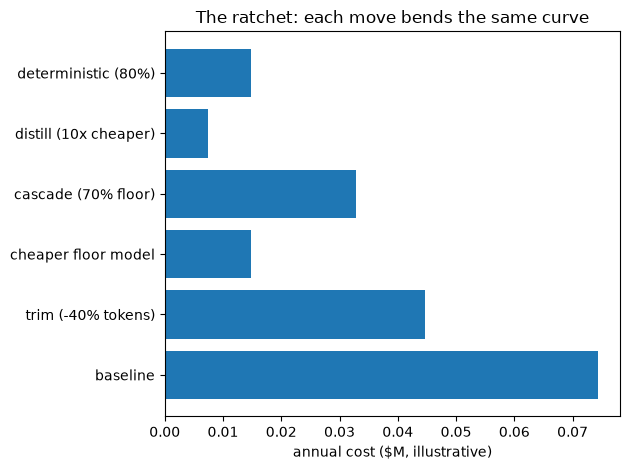

In [4]:
names = list(ratchet.keys())
def _args(kw):
    a = {"input_tokens": 1500, "output_tokens": 600}
    a.update(kw)
    return a
vals = [invoice(**_args(kw))["annual"] / 1e6 for kw in ratchet.values()]
fig, ax = plt.subplots()
ax.barh(names, vals)
ax.set_xlabel("annual cost ($M, illustrative)")
ax.set_title("The ratchet: each move bends the same curve")
plt.tight_layout()
plt.show()

## Interpretation
- Supports: per-call cents become annual millions through ops×users×retries; the verifier sets the ceiling on how far down the ratchet you may go.
- Does NOT support: any vendor pricing claim; edit the parameters.

## Try it yourself
1. Set `retry_rate=0.25` and watch the annual figure move.
2. Add your real token counts and prices.
3. Model a cache hit rate of 40% on repeated prompts.